In [1]:
import numpy as np
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from IPython.display import display
from sklearn.datasets import load_iris

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, Normalizer
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score 
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, TunedThresholdClassifierCV, FixedThresholdClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import balanced_accuracy_score

from sklearn.utils.validation import column_or_1d

import sklearn

sklearn.__version__

'1.9.0'

**Загрузим данные и сделаем задачу бинарной классификации**

In [2]:
# from sklearn.datasets import fetch_openml
# X, y_cat = fetch_openml(data_id=1464, return_X_y=True, parser='auto')
X = pd.read_csv('dataset/data_id_1464_X.csv')
y_cat = pd.read_csv('dataset/data_id_1464_y_cat.csv')
y = np.where(y_cat==1,0,1).reshape(-1) # КОНТРОЛЬ РАЗМЕРНОСТИ, нужен всегда список
y

array([1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [3]:
X.describe()

,V1,V2,V3,V4
count,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.514706,1378.676471,34.282086
std,8.095396,5.839307,1459.826781,24.376714
min,0.000000,1.000000,250.000000,2.000000
25%,2.750000,2.000000,500.000000,16.000000
50%,7.000000,4.000000,1000.000000,28.000000
75%,14.000000,7.000000,1750.000000,50.000000
max,74.000000,50.000000,12500.000000,98.000000


In [4]:
np.array(y).mean()

np.float64(0.23796791443850268)

Сплитуем данные и отложим тестовый набор. Так как данных мало стратифицируем.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, 
                                                     test_size=0.3, stratify=y)

In [6]:
print(np.mean(y_train), np.mean(y_test))

0.23709369024856597 0.24


In [7]:
len(y_test)

225

## Построим построим базовый контейнер для исходной -`origin` модели

In [8]:
model_origin = make_pipeline(StandardScaler(), LogisticRegression())
model_origin

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio 

## Валидация модели `origin`

Так как данных не слишком много, а хочетстся понадежнее поработать с валидацией используем `RepeatedStratifiedKFold` для повторного прохождения на уникальных фолдах.

In [9]:
scoring = ["accuracy", "balanced_accuracy"]
cv_scores = [
    "train_accuracy",
    "test_accuracy",
    "train_balanced_accuracy",
    "test_balanced_accuracy",
]
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
cv_results_model_origin = pd.DataFrame(
    cross_validate(
        model_origin,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        return_train_score=True,
        return_estimator=True,
    )
)
cv_results_model_origin[cv_scores].agg(["mean", "std"]).T

,mean,std
train_accuracy,0.773184,0.006625
test_accuracy,0.769223,0.018808
train_balanced_accuracy,0.545707,0.015395
test_balanced_accuracy,0.541715,0.029941


## Поиск оптимального порога

In [10]:
model_tuned = TunedThresholdClassifierCV(estimator=model_origin, scoring="balanced_accuracy")
cv_results_model_tuned = pd.DataFrame(
    cross_validate(
        model_tuned,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        return_train_score=True,
        return_estimator=True,
    )
)
cv_results_model_tuned[cv_scores].agg(["mean", "std"]).T

,mean,std
train_accuracy,0.677195,0.022884
test_accuracy,0.668458,0.049662
train_balanced_accuracy,0.689079,0.012382
test_balanced_accuracy,0.674181,0.042814


Кстати всего построено (моделей количество фолдов)$\times$(количество повторов) или `n_splits`$\times$`n_repeats`:

In [11]:
len(cv_results_model_tuned)

50

Лучший порог подобранный по отдельности для каждой модели

In [12]:
[est.best_threshold_ for est in cv_results_model_tuned["estimator"]][:10]

[np.float64(0.2766295048131445),
 np.float64(0.26294919104555226),
 np.float64(0.26539672141738974),
 np.float64(0.2831297471875591),
 np.float64(0.2640206035750998),
 np.float64(0.2482452700743794),
 np.float64(0.24355647495358998),
 np.float64(0.270024328857198),
 np.float64(0.2489781515446935),
 np.float64(0.29124156231340254)]

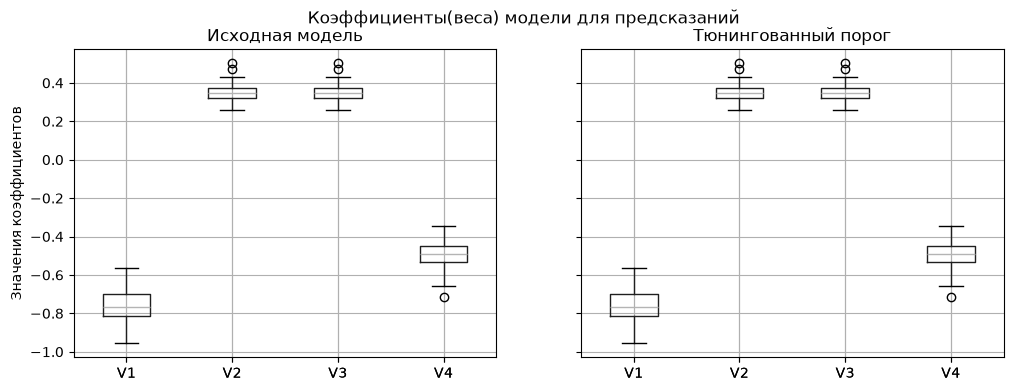

In [13]:
model_origin_coef = pd.DataFrame(
    [est[-1].coef_.ravel() for est in cv_results_model_origin["estimator"]],
    columns=X.columns,
)
model_tuned_coef = pd.DataFrame(
    [est.estimator_[-1].coef_.ravel() for est in cv_results_model_tuned["estimator"]],
    columns=X.columns,
)

fig, ax = plt.subplots(ncols=2, figsize=(12, 4), sharex=True, sharey=True)
model_origin_coef.boxplot(ax=ax[0])
ax[0].set_ylabel("Значения коэффициентов")
ax[0].set_title("Исходная модель")
model_tuned_coef.boxplot(ax=ax[1])
ax[1].set_title("Тюнингованный порог")
_ = fig.suptitle("Коэффициенты(веса) модели для предсказаний")

Обратите внимание **после тюнинга порога это одна и таже модель, коэффициенты не изменились!**

### Какой порог выбрать?

Важный вопрос к обсужению: 
- что такое мода и почему ее не найти в виде статистической функции, почему мы ищем максимум на pdf-функции.
- как надтянуть pdf-функцию на данные.

(array([1., 2., 0., 1., 0., 4., 3., 2., 3., 2., 2., 3., 1., 2., 5., 1., 3.,
        2., 0., 3., 2., 0., 0., 2., 2., 0., 0., 1., 1., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([0.23734475, 0.23921607, 0.24108739, 0.24295871, 0.24483002,
        0.24670134, 0.24857266, 0.25044398, 0.2523153 , 0.25418662,
        0.25605794, 0.25792925, 0.25980057, 0.26167189, 0.26354321,
        0.26541453, 0.26728585, 0.26915716, 0.27102848, 0.2728998 ,
        0.27477112, 0.27664244, 0.27851376, 0.28038507, 0.28225639,
        0.28412771, 0.28599903, 0.28787035, 0.28974167, 0.29161299,
        0.2934843 , 0.29535562, 0.29722694, 0.29909826, 0.30096958,
        0.3028409 , 0.30471221, 0.30658353, 0.30845485, 0.31032617,
        0.31219749, 0.31406881, 0.31594013, 0.31781144, 0.31968276,
        0.32155408, 0.3234254 , 0.32529672, 0.32716804, 0.32903935,
        0.33091067]),
 <BarContainer object of 50 artists>)

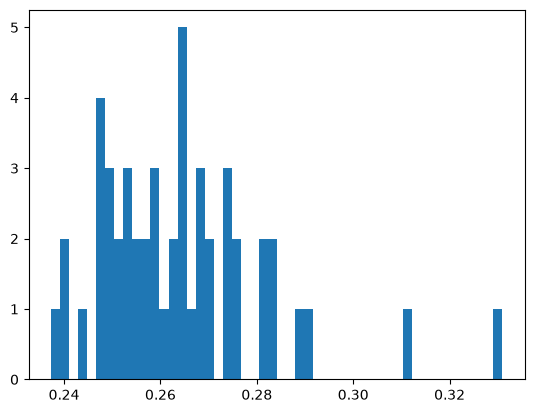

In [14]:
decision_threshold = pd.Series(
    [est.best_threshold_ for est in cv_results_model_tuned["estimator"]],
)

plt.hist(decision_threshold, bins=50)

In [15]:
stats.mode(decision_threshold)# .mode  .count

ModeResult(mode=np.float64(0.23734475058741147), count=np.int64(1))

In [16]:
decision_threshold.median()

np.float64(0.26237205874663533)

In [17]:
decision_threshold.mean()

np.float64(0.26417707881545355)

Почему же мы получили столь странное значение моды?

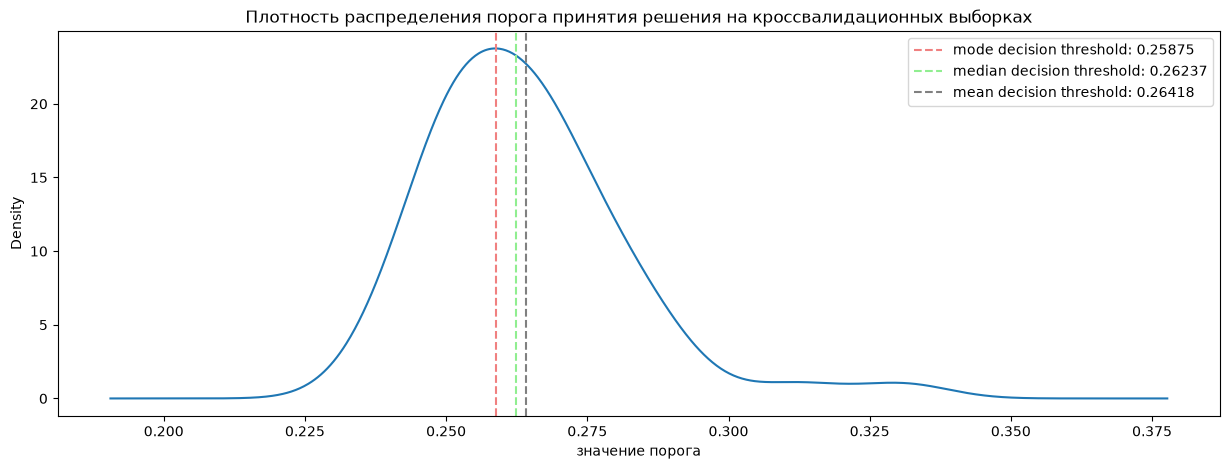

In [18]:

fig, ax = plt.subplots(figsize=(15,5))

ax = decision_threshold.plot.kde(bw_method=None) #bw_method=0.3 'scott', 'silverman',
line = ax.get_lines() # забрал список отрисованных линий
x_plt, y_plt = line[0].get_data() # из списка взял нужную линию для разборки по точкам 

ths = {
    'mode':   [x_plt[np.argmax(y_plt)],'lightcoral'],
    'median': [decision_threshold.median(), 'lightgreen'],
    'mean':   [decision_threshold.mean(),  'gray']
}

for key in ths.keys():
    ax.axvline(
        ths[key][0],
        color=ths[key][1],
        linestyle="--",
        label=f"{key} decision threshold: {ths[key][0]:.5f}",
    )

ax.set_xlabel("значение порога")
ax.legend(loc="upper right")
_ = ax.set_title(
    "Плотность распределения порога принятия решения на кроссвалидационных выборках"
)

In [19]:
ths_final = {
    'origin': 0.5,
    'mode':   x_plt[np.argmax(y_plt)],
    'median': decision_threshold.median(),
    'mean':   decision_threshold.mean(),
}
comparison =pd.DataFrame()
for key in ths_final:
    final_tune = FixedThresholdClassifier(model_origin, threshold=ths_final[key]).fit(X_train, y_train)
    comparison.loc[key,'train']= balanced_accuracy_score(y_train, final_tune.predict(X_train))
    comparison.loc[key,'test'] = balanced_accuracy_score(y_test, final_tune.predict(X_test))

comparison.sort_values(by='test')

,train,test
origin,0.545173,0.537524
mode,0.693730,0.729045
median,0.692204,0.731969
mean,0.692204,0.731969
